In [ ]:
import pandas as pd
housing = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv')

# import polars as pl
# housing = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv')

Dataset shape: (20000, 21)
           id             date  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  1565930130  20141104T000000         4       3.25         3760      4675   
1  3279000420  20150115T000000         3       1.75         1460      7800   
2   194000575  20141014T000000         4       1.00         1340      5800   
3  2115510160  20141208T000000         3       1.75         1440      8050   
4  7522500005  20140815T000000         2       1.50         1780      4750   

   floors  waterfront  view  condition  ...  sqft_above  sqft_basement  \
0     2.0           0     0          3  ...        2740           1020   
1     1.0           0     0          2  ...        1040            420   
2     1.5           0     2          3  ...        1340              0   
3     1.0           0     0          3  ...        1440              0   
4     1.0           0     0          4  ...        1080            700   

   yr_built  yr_renovated  zipcode      lat     long  sqft_

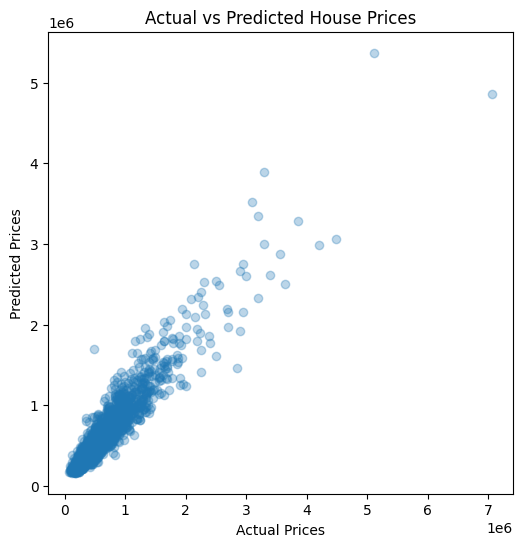

Pipeline complete.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


housing = pd.read_csv(
    'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv'
)

print("Dataset shape:", housing.shape)
print(housing.head())



housing.replace([np.inf, -np.inf], np.nan, inplace=True)


housing['house_age'] = 2026 - housing['yr_built']
housing['sqft_per_bedroom'] = housing['sqft_living'] / housing['bedrooms'].replace(0, 1)
housing['living_to_lot_ratio'] = housing['sqft_living'] / housing['sqft_lot']


y = housing['price']
X = housing.drop(['price', 'id', 'date'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)



model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)


clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])


clf.fit(X_train, y_train)

print("Model training complete.")


predictions = clf.predict(X_test)



mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n========================")
print("MODEL PERFORMANCE")
print("========================")
print("MSE:", mse)
print("R2 Score:", r2)



plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

print("Pipeline complete.")

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor


train_url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv"
housing = pd.read_csv(train_url)


housing.replace([np.inf, -np.inf], np.nan, inplace=True)


housing["house_age"] = 2026 - housing["yr_built"]
housing["sqft_per_bedroom"] = housing["sqft_living"] / housing["bedrooms"].replace(0, 1)
housing["living_to_lot_ratio"] = housing["sqft_living"] / housing["sqft_lot"]


y = housing["price"]
X = housing.drop(["price", "id", "date"], axis=1)



numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X, y)

print("Model trained on full dataset.")


test_url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing_holdout_test.csv"
test_data = pd.read_csv(test_url)

test_ids = test_data["id"]


test_data.replace([np.inf, -np.inf], np.nan, inplace=True)

test_data["house_age"] = 2026 - test_data["yr_built"]
test_data["sqft_per_bedroom"] = test_data["sqft_living"] / test_data["bedrooms"].replace(0, 1)
test_data["living_to_lot_ratio"] = test_data["sqft_living"] / test_data["sqft_lot"]

X_test_final = test_data.drop(["id", "date"], axis=1)



predictions = pipeline.predict(X_test_final)



output = pd.DataFrame({
    "price": predictions
})

output.to_csv("team3-module3-predictions.csv", index=False)

print("CSV file created: team3-module3-predictions.csv")
print(output.head())

Model trained on full dataset.
CSV file created: team3-module3-predictions.csv
          price
0  4.031122e+05
1  8.693161e+05
2  1.141685e+06
3  2.142936e+06
4  7.132629e+05
